<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/17_forex_reserves_var_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

# Fix random seed for reproducible econometric modeling
np.random.seed(42)
DAYS = 250

# Mean daily returns and annualized volatilities
# Asset allocations: US Treasuries, Gold, Euro Sovereign Bonds, IMF SDRs
mean_returns = np.array([0.00015, 0.00030, 0.00010, 0.00008])

# Correlation matrix across reserve classes
corr_matrix = np.array(
    [
        [1.00, -0.15, 0.35, 0.40],  # US Treasuries
        [-0.15, 1.00, 0.10, 0.05],  # Gold
        [0.35, 0.10, 1.00, 0.50],  # Euro Bonds
        [0.40, 0.05, 0.50, 1.00],  # SDR Basket
    ]
)

# Daily standard deviations (~8% to 16% annualized)
volatilities = np.array([0.0050, 0.0105, 0.0062, 0.0038])

# Compute covariance matrix: Cov = Diag(vol) * Corr * Diag(vol)
cov_matrix = np.outer(volatilities, volatilities) * corr_matrix

# Simulate joint normal daily returns
daily_returns = np.random.multivariate_normal(
    mean_returns, cov_matrix, size=DAYS
)

df_returns = pd.DataFrame(
    daily_returns,
    columns=["US_Treasuries", "Gold", "Euro_Bonds", "SDR_Basket"],
)
df_returns.to_csv("forex_reserves_returns.csv", index=False)

print(
    f"Simulated {DAYS} trading days of multi-asset sovereign reserve returns."
)
print(df_returns.head())

Simulated 250 trading days of multi-asset sovereign reserve returns.
   US_Treasuries      Gold  Euro_Bonds  SDR_Basket
0       0.001285  0.005667   -0.001348    0.005005
1       0.006110 -0.001552   -0.002926    0.003353
2      -0.002544 -0.004661   -0.001964   -0.002902
3       0.000668  0.001595    0.015455    0.002858
4      -0.002157 -0.010558    0.000609   -0.005228


In [2]:
df_returns = pd.read_csv("forex_reserves_returns.csv")

# Asset Allocation Weights (must sum to 1.0)
weights = np.array([0.60, 0.15, 0.18, 0.07])
PORTFOLIO_VALUE_USD_BN = 650.0  # $650 Billion Total Reserve Base

# Calculate daily portfolio returns: R_p = w · R
df_returns["Portfolio_Return"] = df_returns.dot(weights)

# Portfolio moments
port_mean = df_returns["Portfolio_Return"].mean()
port_std = df_returns["Portfolio_Return"].std()

# Portfolio variance via covariance matrix: w^T * Cov * w
sample_cov = df_returns[
    ["US_Treasuries", "Gold", "Euro_Bonds", "SDR_Basket"]
].cov()
portfolio_variance = np.dot(weights.T, np.dot(sample_cov, weights))
portfolio_vol_calc = np.sqrt(portfolio_variance)

print("--- Sovereign Reserve Portfolio Profile ---")
print(f"Total Reserve Value:        ${PORTFOLIO_VALUE_USD_BN:.1f} Billion")
print(f"Expected Daily Return:      {port_mean * 100:.4f}%")
print(f"Daily Volatility (Std Dev): {port_std * 100:.4f}%")
print(
    f"Annualized Volatility:      {port_std * np.sqrt(252) * 100:.2f}%\n"
)
print("--- Asset Covariance Matrix ---")
print(sample_cov.round(6))

--- Sovereign Reserve Portfolio Profile ---
Total Reserve Value:        $650.0 Billion
Expected Daily Return:      0.0109%
Daily Volatility (Std Dev): 0.3779%
Annualized Volatility:      6.00%

--- Asset Covariance Matrix ---
               US_Treasuries      Gold  Euro_Bonds  SDR_Basket
US_Treasuries       0.000024 -0.000007    0.000010    0.000006
Gold               -0.000007  0.000091    0.000009    0.000004
Euro_Bonds          0.000010  0.000009    0.000042    0.000011
SDR_Basket          0.000006  0.000004    0.000011    0.000013


In [3]:
conf_levels = [0.95, 0.99]
results = []

for cl in conf_levels:
    alpha = 1 - cl
    z_score = norm.ppf(cl)

    # 1. Parametric VaR
    param_var_pct = -(port_mean - z_score * port_std)
    param_var_usd = param_var_pct * PORTFOLIO_VALUE_USD_BN

    # 2. Historical Simulation VaR
    hist_var_pct = -df_returns["Portfolio_Return"].quantile(alpha)
    hist_var_usd = hist_var_pct * PORTFOLIO_VALUE_USD_BN

    # 3. Expected Shortfall (CVaR) - Tail Conditional Expectation
    tail_losses = df_returns.loc[
        df_returns["Portfolio_Return"] <= -hist_var_pct, "Portfolio_Return"
    ]
    cvar_pct = -tail_losses.mean()
    cvar_usd = cvar_pct * PORTFOLIO_VALUE_USD_BN

    results.append(
        {
            "Confidence_Level": f"{int(cl*100)}%",
            "Parametric_VaR_%": param_var_pct * 100,
            "Parametric_VaR_$Bn": param_var_usd,
            "Historical_VaR_%": hist_var_pct * 100,
            "Historical_VaR_$Bn": hist_var_usd,
            "Expected_Shortfall_$Bn": cvar_usd,
        }
    )

df_risk = pd.DataFrame(results).set_index("Confidence_Level")

print("--- 1-Day Horizon Risk Diagnostics ($650B Reserve Base) ---")
print(df_risk.round(2))

--- 1-Day Horizon Risk Diagnostics ($650B Reserve Base) ---
                  Parametric_VaR_%  Parametric_VaR_$Bn  Historical_VaR_%  \
Confidence_Level                                                           
95%                           0.61                3.97              0.65   
99%                           0.87                5.64              0.78   

                  Historical_VaR_$Bn  Expected_Shortfall_$Bn  
Confidence_Level                                              
95%                             4.24                    4.96  
99%                             5.08                    6.25  


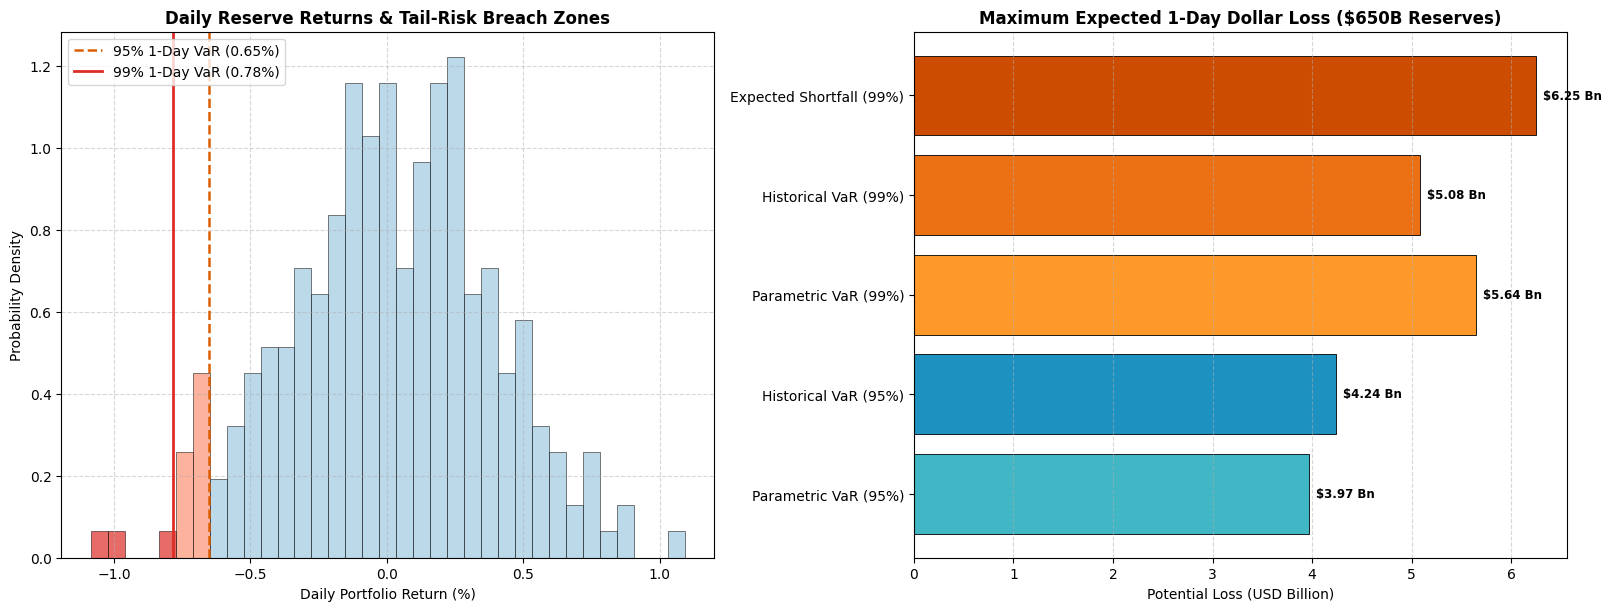

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), layout="constrained")

port_rets = df_returns["Portfolio_Return"] * 100  # in percentage
var_95 = df_risk.loc["95%", "Historical_VaR_%"]
var_99 = df_risk.loc["99%", "Historical_VaR_%"]

# --- Chart 1: Return Distribution with VaR & Tail Risk ---
n, bins, patches = ax1.hist(
    port_rets,
    bins=35,
    density=True,
    color="#9ecae1",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.7,
)

# Highlight tail losses exceeding 95% VaR
for bin_left, patch in zip(bins[:-1], patches):
    if bin_left <= -var_99:
        patch.set_facecolor("#de2d26")  # Severe tail (>99%)
    elif bin_left <= -var_95:
        patch.set_facecolor("#fc9272")  # 95% to 99% tail

ax1.axvline(
    -var_95,
    color="#d95f02",
    linestyle="--",
    linewidth=1.8,
    label=f"95% 1-Day VaR ({var_95:.2f}%)",
)
ax1.axvline(
    -var_99,
    color="#de2d26",
    linestyle="-",
    linewidth=2.0,
    label=f"99% 1-Day VaR ({var_99:.2f}%)",
)

ax1.set_title(
    "Daily Reserve Returns & Tail-Risk Breach Zones", fontsize=12, weight="bold"
)
ax1.set_xlabel("Daily Portfolio Return (%)")
ax1.set_ylabel("Probability Density")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")

# --- Chart 2: Dollar-Value Tail Risk Exposure ($ Billion Loss) ---
risk_labels = [
    "Parametric VaR (95%)",
    "Historical VaR (95%)",
    "Parametric VaR (99%)",
    "Historical VaR (99%)",
    "Expected Shortfall (99%)",
]
loss_values = [
    df_risk.loc["95%", "Parametric_VaR_$Bn"],
    df_risk.loc["95%", "Historical_VaR_$Bn"],
    df_risk.loc["99%", "Parametric_VaR_$Bn"],
    df_risk.loc["99%", "Historical_VaR_$Bn"],
    df_risk.loc["99%", "Expected_Shortfall_$Bn"],
]

bar_colors = ["#41b6c4", "#1d91c0", "#fe9929", "#ec7014", "#cc4c02"]
bars = ax2.barh(
    risk_labels, loss_values, color=bar_colors, edgecolor="black", linewidth=0.6
)

ax2.set_title(
    "Maximum Expected 1-Day Dollar Loss ($650B Reserves)",
    fontsize=12,
    weight="bold",
)
ax2.set_xlabel("Potential Loss (USD Billion)")
ax2.grid(axis="x", linestyle="--", alpha=0.5)

for bar in bars:
    width = bar.get_width()
    ax2.annotate(
        f"${width:.2f} Bn",
        (width, bar.get_y() + bar.get_height() / 2),
        textcoords="offset points",
        xytext=(5, 0),
        va="center",
        fontsize=8.5,
        weight="bold",
    )

plt.show()